In [2]:
import pandas as pd

df = pd.read_csv("ai_datacenter_locations.csv")

df.head()

,Country,Electricity_Cost,Renewable_Energy,Average_Temperature,AI_Demand
0,United States,0.18,25,15,95
1,Canada,0.12,68,4,70
2,Norway,0.11,98,2,50
3,Singapore,0.26,5,29,90
4,South Korea,0.15,12,13,85


In [3]:
df["Deployment_Score"] = (
    (100 - df["Electricity_Cost"] * 100) * 0.35 +
    df["Renewable_Energy"] * 0.35 +
    (100 - df["Average_Temperature"] * 2) * 0.15 +
    df["AI_Demand"] * 0.15
)

df.sort_values("Deployment_Score", ascending=False)

,Country,Electricity_Cost,Renewable_Energy,Average_Temperature,AI_Demand,Deployment_Score
2,Norway,0.11,98,2,50,87.35
9,Sweden,0.13,80,5,60,80.95
1,Canada,0.12,68,4,70,78.90
6,France,0.17,55,11,75,71.25
5,Germany,0.22,46,10,80,67.40
0,United States,0.18,25,15,95,62.20
8,Australia,0.21,35,21,65,58.35
4,South Korea,0.15,12,13,85,57.80
7,Japan,0.24,20,16,88,57.00
3,Singapore,0.26,5,29,90,47.45


In [4]:
df.to_csv("deployment_analysis.csv", index=False)

In [5]:
import pandas as pd
import numpy as np

countries = [
    "United States","Canada","Norway","Sweden","Finland","Denmark",
    "Germany","France","Netherlands","United Kingdom",
    "Ireland","Switzerland","Austria","Belgium","Spain",
    "Portugal","Italy","Poland","Czech Republic","Hungary",
    "Singapore","Japan","South Korea","Taiwan","Australia",
    "New Zealand","United Arab Emirates","Saudi Arabia","Qatar","Israel",
    "India","China","Malaysia","Thailand","Vietnam",
    "Indonesia","Philippines","Brazil","Mexico","Chile",
    "Argentina","South Africa","Egypt","Turkey","Greece",
    "Luxembourg","Iceland","Estonia","Latvia","Lithuania"
]

np.random.seed(42)

df = pd.DataFrame({
    "Country": countries,
    "Electricity_Cost": np.random.uniform(0.08,0.35,len(countries)).round(2),
    "Renewable_Energy": np.random.randint(5,100,len(countries)),
    "Average_Temperature": np.random.randint(2,35,len(countries)),
    "AI_Demand": np.random.randint(40,100,len(countries))
})

df["Deployment_Score"] = (
    (100 - df["Electricity_Cost"]*100)*0.35 +
    df["Renewable_Energy"]*0.35 +
    (100 - df["Average_Temperature"]*2)*0.15 +
    df["AI_Demand"]*0.15
).round(2)

df = df.sort_values("Deployment_Score", ascending=False)

df.head()

,Country,Electricity_Cost,Renewable_Energy,Average_Temperature,AI_Demand,Deployment_Score
8,Netherlands,0.24,99,2,88,88.85
13,Belgium,0.14,91,10,78,85.65
22,South Korea,0.16,93,24,88,82.95
5,Denmark,0.12,78,2,63,81.95
29,Israel,0.09,93,29,71,81.35


In [6]:
import sqlite3

conn = sqlite3.connect("deployment.db")

df.to_sql(
    "deployment_data",
    conn,
    if_exists="replace",
    index=False
)

query = """
SELECT Country,
       Deployment_Score
FROM deployment_data
ORDER BY Deployment_Score DESC
LIMIT 10;
"""

top_locations = pd.read_sql(query, conn)

top_locations

,Country,Deployment_Score
0,Netherlands,88.85
1,Belgium,85.65
2,South Korea,82.95
3,Denmark,81.95
4,Israel,81.35
5,Italy,80.65
6,Norway,79.55
7,Poland,78.90
8,Malaysia,78.70
9,Estonia,77.80


In [7]:
df.to_csv(
    "deployment_analysis.csv",
    index=False
)

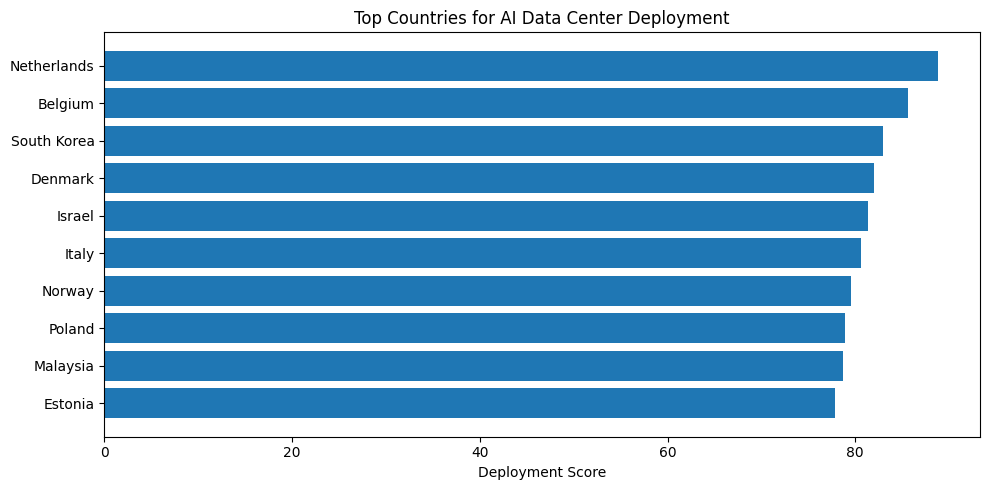

In [8]:
import matplotlib.pyplot as plt

top10 = df.head(10)

plt.figure(figsize=(10,5))
plt.barh(
    top10["Country"],
    top10["Deployment_Score"]
)
plt.xlabel("Deployment Score")
plt.title("Top Countries for AI Data Center Deployment")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig(
    "deployment_ranking.png",
    dpi=300
)

plt.show()

In [9]:
df.to_csv("deployment_analysis_50.csv", index=False)

In [10]:
len(df)

50

In [11]:
df.to_csv(
    "deployment_analysis_50.csv",
    index=False
)

In [12]:
pd.read_csv("deployment_analysis_50.csv").shape

(50, 6)